Company : BA, BAESY, CD

In [20]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from scipy.optimize import minimize
import os

1. Dataset

In [21]:
import pandas as pd

START_DATE = "2023-01-04"
DATA_DIR   = "../../data/Secteur_Aerospace"
OUTPUT_DIR = "../json"

ba = pd.read_csv(f"{DATA_DIR}/BA.csv")
ba = ba[["Date", "Adj Close"]].copy()
ba.columns = ["Date", "X_t"]

baesy = pd.read_csv(f"{DATA_DIR}/BAESY.csv")
baesy = baesy[["Date", "Adj Close"]].copy()
baesy.columns = ["Date", "X_t"]

gd = pd.read_csv(f"{DATA_DIR}/GD.csv")
gd = gd[["Date", "Adj Close"]].copy()
gd.columns = ["Date", "X_t"]

In [22]:
ba.head()

,Date,X_t
0,2023-01-03,195.39
1,2023-01-04,203.64
2,2023-01-05,204.99
3,2023-01-06,213.00
4,2023-01-09,208.57


2. Data preprocessing

In [23]:
ba["Date"] = pd.to_datetime(ba["Date"])
ba = ba[ba["Date"] >= pd.Timestamp(START_DATE)].copy()
ba = ba.sort_values("Date").dropna().reset_index(drop=True)

baesy["Date"] = pd.to_datetime(baesy["Date"])
baesy = baesy[baesy["Date"] >= pd.Timestamp(START_DATE)].copy()
baesy = baesy.sort_values("Date").dropna().reset_index(drop=True)

gd["Date"] = pd.to_datetime(gd["Date"])
gd = gd[gd["Date"] >= pd.Timestamp(START_DATE)].copy()
gd = gd.sort_values("Date").dropna().reset_index(drop=True)


print("BA shape:    ", ba.shape)
print("BAESY shape: ", baesy.shape)
print("GD shape:    ", gd.shape)

BA shape:     (770, 2)
BAESY shape:  (770, 2)
GD shape:     (770, 2)


3. Compute the Hanning filtered series

In [24]:
ba["Y_t"] = (
    0.25 * ba["X_t"].shift(1) +
    0.50 * ba["X_t"] +
    0.25 * ba["X_t"].shift(-1)
)
ba = ba.dropna(subset=["Y_t"]).reset_index(drop=True)

baesy["Y_t"] = (
    0.25 * baesy["X_t"].shift(1) +
    0.50 * baesy["X_t"] +
    0.25 * baesy["X_t"].shift(-1)
)
baesy = baesy.dropna(subset=["Y_t"]).reset_index(drop=True)

gd["Y_t"] = (
    0.25 * gd["X_t"].shift(1) +
    0.50 * gd["X_t"] +
    0.25 * gd["X_t"].shift(-1)
)
gd = gd.dropna(subset=["Y_t"]).reset_index(drop=True)

4. Plot raw and filtered series

In [25]:
def plot_raw_and_filtered(df, ticker):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(df["Date"], df["X_t"], lw=1)
    axes[0].set_title(f"Raw Series (Adj Close) - {ticker}")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("X_t")
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

    axes[1].plot(df["Date"], df["Y_t"], lw=1.5)
    axes[1].set_title(f"Hanning Filtered Series - {ticker}")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Y_t")
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

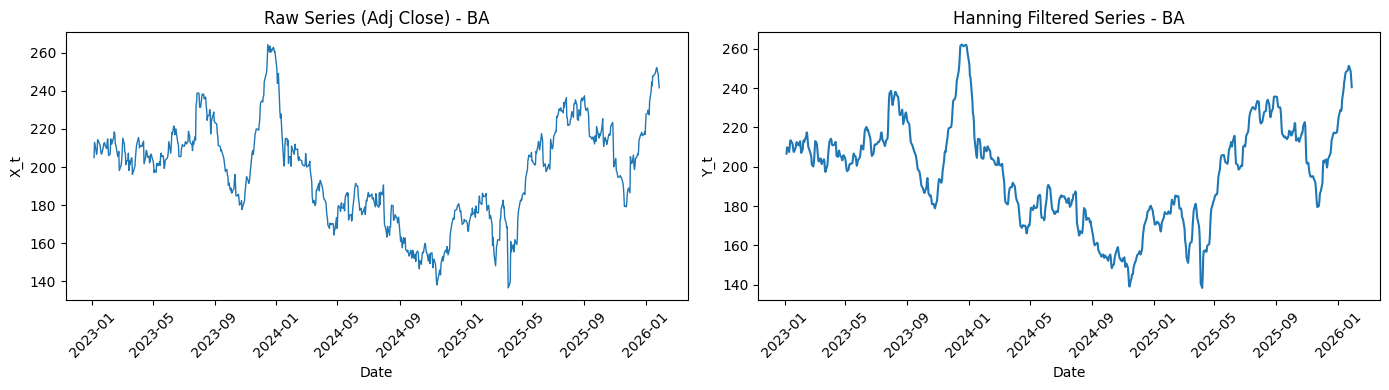

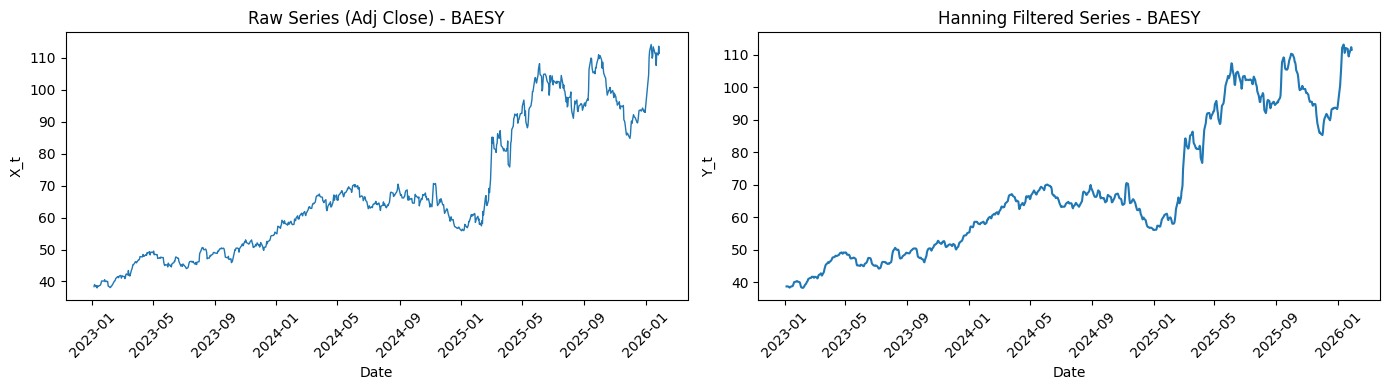

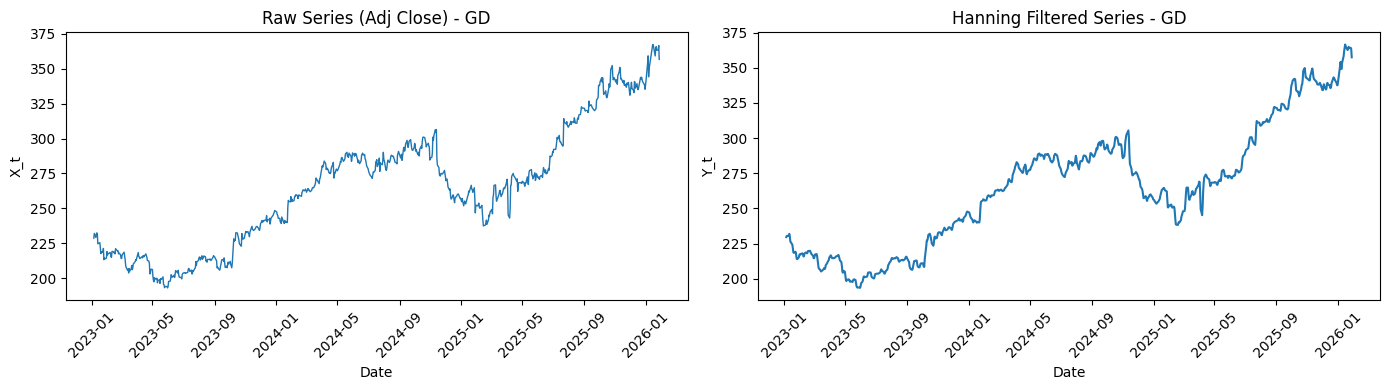

In [26]:
plot_raw_and_filtered(ba, "BA")
plot_raw_and_filtered(baesy, "BAESY")
plot_raw_and_filtered(gd, "GD")

5. Define the skew-normal model functions

In [27]:
def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)


def neg_loglik_common_theta(params, y_left, y_right):
    mu1, log_sigma1, mu2, log_sigma2, theta = params

    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)

    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf

    pdf1 = np.clip(skew_normal_pdf(y_left, mu1, sigma1, theta), 1e-12, None)
    pdf2 = np.clip(skew_normal_pdf(y_right, mu2, sigma2, theta), 1e-12, None)

    return -(np.sum(np.log(pdf1)) + np.sum(np.log(pdf2)))

6. Estimate the skew-normal parameters before and after rupture

In [28]:
def fit_sn_two_regimes(Y, k):
    y1 = Y[:k]
    y2 = Y[k:]

    mu1_init = float(np.mean(y1))
    mu2_init = float(np.mean(y2))
    sigma1_init = max(float(np.std(y1, ddof=0)), 1e-3)
    sigma2_init = max(float(np.std(y2, ddof=0)), 1e-3)

    x0 = np.array([
        mu1_init, np.log(sigma1_init),
        mu2_init, np.log(sigma2_init),
        0.0
    ])

    result = minimize(
        neg_loglik_common_theta,
        x0=x0,
        args=(y1, y2),
        method="L-BFGS-B"
    )

    mu1_hat, ls1, mu2_hat, ls2, theta_hat = result.x

    return {
        "mu1": float(mu1_hat),
        "sigma1": float(np.exp(ls1)),
        "mu2": float(mu2_hat),
        "sigma2": float(np.exp(ls2)),
        "theta": float(theta_hat),
        "n1": len(y1),
        "n2": len(y2),
        "negll": float(result.fun),
        "success": bool(result.success),
        "message": result.message
    }

7. Scan candidate rupture points with the KS test

In [29]:
def ks_scan(Y, min_segment_size=30):
    n = len(Y)

    k_values = []
    ks_stats = []
    p_values = []

    for k in range(min_segment_size, n - min_segment_size + 1):
        stat, pval = ks_2samp(Y[:k], Y[k:])
        k_values.append(k)
        ks_stats.append(stat)
        p_values.append(pval)

    best_index = int(np.argmax(ks_stats))

    return {
        "k_values": k_values,
        "ks_stats": ks_stats,
        "p_values": p_values,
        "k_hat": int(k_values[best_index]),
        "best_ks": float(ks_stats[best_index]),
        "best_pval": float(p_values[best_index])
    }


def build_verdict(p_value, alpha=0.05):
    if p_value < alpha:
        return f"Reject H0 at {alpha:.2f}: evidence of a rupture"
    return f"Fail to reject H0 at {alpha:.2f}: no strong evidence of a rupture"

8. Full analysis for one company

In [30]:
def analyze_company(df, ticker, company_name, company_url):
    Y = df["Y_t"].to_numpy()

    scan = ks_scan(Y, min_segment_size=30)
    k_hat = scan["k_hat"]
    best_ks = scan["best_ks"]
    best_pval = scan["best_pval"]
    break_date = df.loc[k_hat, "Date"]
    verdict = build_verdict(best_pval)

    fit = fit_sn_two_regimes(Y, k_hat)

    mu1_hat = fit["mu1"]
    sigma1_hat = fit["sigma1"]
    mu2_hat = fit["mu2"]
    sigma2_hat = fit["sigma2"]
    theta_hat = fit["theta"]

    y1 = Y[:k_hat]
    y2 = Y[k_hat:]

    interpretation = (
        f"For {ticker}, the estimated rupture point is k_hat = {k_hat} "
        f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
        f"p-value is {best_pval:.4f}. Decision: {verdict}. "
        f"The skew-normal estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
        f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
    )

    xg1 = np.linspace(y1.min(), y1.max(), 300)
    pdf1 = skew_normal_pdf(xg1, mu1_hat, sigma1_hat, theta_hat)

    xg2 = np.linspace(y2.min(), y2.max(), 300)
    pdf2 = skew_normal_pdf(xg2, mu2_hat, sigma2_hat, theta_hat)

    result = {
        "company": ticker,
        "name": company_name,
        "url": company_url,
        "k_hat": int(k_hat),
        "bp_date": str(break_date.date()),
        "D": round(best_ks, 6),
        "p_value": round(best_pval, 6),
        "reject_H0": bool(best_pval < 0.05),
        "verdict": verdict,
        "mu1": round(mu1_hat, 6),
        "sigma1": round(sigma1_hat, 6),
        "mu2": round(mu2_hat, 6),
        "sigma2": round(sigma2_hat, 6),
        "theta": round(theta_hat, 6),
        "n1": fit["n1"],
        "n2": fit["n2"],
        "negll": round(fit["negll"], 6),
        "optimization_success": fit["success"],
        "optimization_message": fit["message"],
        "interpretation": interpretation,
        "chart_data": {
            "dates": df["Date"].dt.strftime("%Y-%m-%d").tolist(),
            "prices": df["X_t"].tolist(),
            "smoothed": df["Y_t"].tolist(),
            "Y": Y.tolist(),
            "scan_k": scan["k_values"],
            "scan_D": scan["ks_stats"],
            "scan_p": scan["p_values"],
            "xg1": xg1.tolist(),
            "pdf1": pdf1.tolist(),
            "xg2": xg2.tolist(),
            "pdf2": pdf2.tolist()
        }
    }

    return result

9. Plot KS scan, breakpoint, and regime distributions

In [31]:
def plot_ks_scan(result):
    ticker = result["company"]
    k_hat = result["k_hat"]
    k_values = result["chart_data"]["scan_k"]
    ks_stats = result["chart_data"]["scan_D"]

    plt.figure(figsize=(10, 4))
    plt.plot(k_values, ks_stats, lw=1.5)
    plt.axvline(k_hat, linestyle="--", label=f"k_hat = {k_hat}")
    plt.title(f"KS Statistic Scan - {ticker}")
    plt.xlabel("Candidate k")
    plt.ylabel("KS statistic")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [32]:
def plot_breakpoint(df, result):
    ticker = result["company"]
    k_hat = result["k_hat"]
    break_date = pd.to_datetime(result["bp_date"])

    Y = df["Y_t"].to_numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(df["Date"][:k_hat], Y[:k_hat], lw=1, label="Regime 1")
    plt.plot(df["Date"][k_hat:], Y[k_hat:], lw=1, label="Regime 2")
    plt.axvline(break_date, linestyle="--", label=f"k_hat = {k_hat}")
    plt.title(f"Breakpoint Detection - {ticker}")
    plt.xlabel("Date")
    plt.ylabel("Y_t")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [33]:
def plot_regime_histograms(df, result):
    ticker = result["company"]
    k_hat = result["k_hat"]

    Y = df["Y_t"].to_numpy()
    y1 = Y[:k_hat]
    y2 = Y[k_hat:]

    mu1_hat = result["mu1"]
    sigma1_hat = result["sigma1"]
    mu2_hat = result["mu2"]
    sigma2_hat = result["sigma2"]
    theta_hat = result["theta"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    x_grid_1 = np.linspace(np.min(y1), np.max(y1), 400)
    axes[0].hist(y1, bins=12, density=True, alpha=0.5)
    axes[0].plot(
        x_grid_1,
        skew_normal_pdf(x_grid_1, mu1_hat, sigma1_hat, theta_hat),
        lw=2,
        label=f"SN(mu={mu1_hat:.4f}, sigma={sigma1_hat:.4f}, theta={theta_hat:.4f})"
    )
    axes[0].set_title(f"{ticker} - Regime 1 (n={len(y1)})")
    axes[0].set_xlabel("Y_t")
    axes[0].set_ylabel("Density")
    axes[0].legend(fontsize=8)

    x_grid_2 = np.linspace(np.min(y2), np.max(y2), 400)
    axes[1].hist(y2, bins=12, density=True, alpha=0.5)
    axes[1].plot(
        x_grid_2,
        skew_normal_pdf(x_grid_2, mu2_hat, sigma2_hat, theta_hat),
        lw=2,
        label=f"SN(mu={mu2_hat:.4f}, sigma={sigma2_hat:.4f}, theta={theta_hat:.4f})"
    )
    axes[1].set_title(f"{ticker} - Regime 2 (n={len(y2)})")
    axes[1].set_xlabel("Y_t")
    axes[1].set_ylabel("Density")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

10. Run the full analysis for the three companies

In [34]:
result_ba = analyze_company(
    ba,
    "BA",
    "Boeing",
    "https://finance.yahoo.com/quote/BA/profile"
)

result_baesy = analyze_company(
    baesy,
    "BAESY",
    "BAE Systems",
    "https://finance.yahoo.com/quote/BAESY/profile"
)

result_gd = analyze_company(
    gd,
    "GD",
    "General Dynamics",
    "https://finance.yahoo.com/quote/GD/profile"
)

11. Show the results and figures for BA

For BA, the estimated rupture point is k_hat = 738 (2025-12-15). The KS statistic is 0.6436 and the p-value is 0.0000. Decision: Reject H0 at 0.05: evidence of a rupture. The skew-normal estimates are mu1 = 195.8357, sigma1 = 25.2167, mu2 = 229.8417, sigma2 = 15.1891, theta = 0.0000.


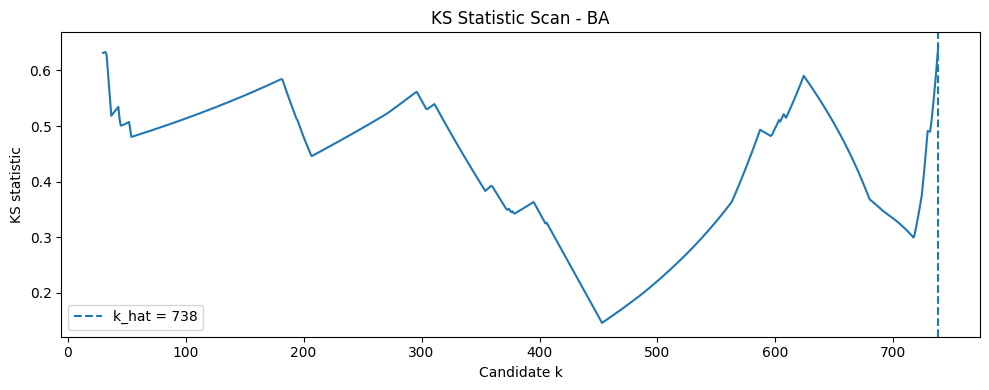

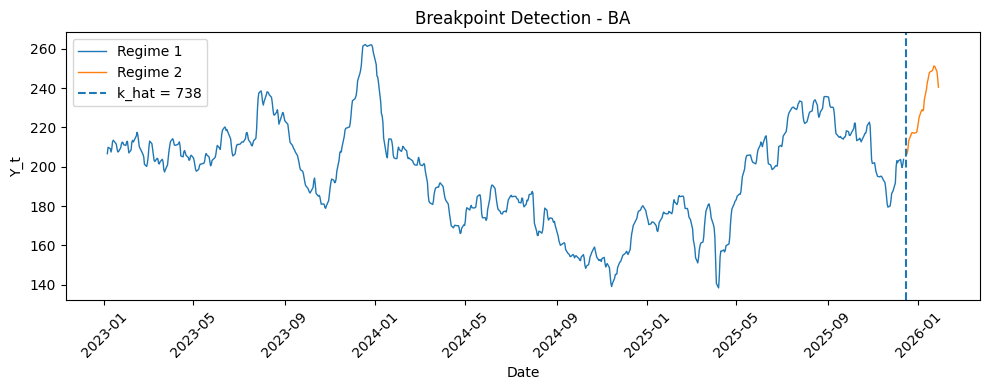

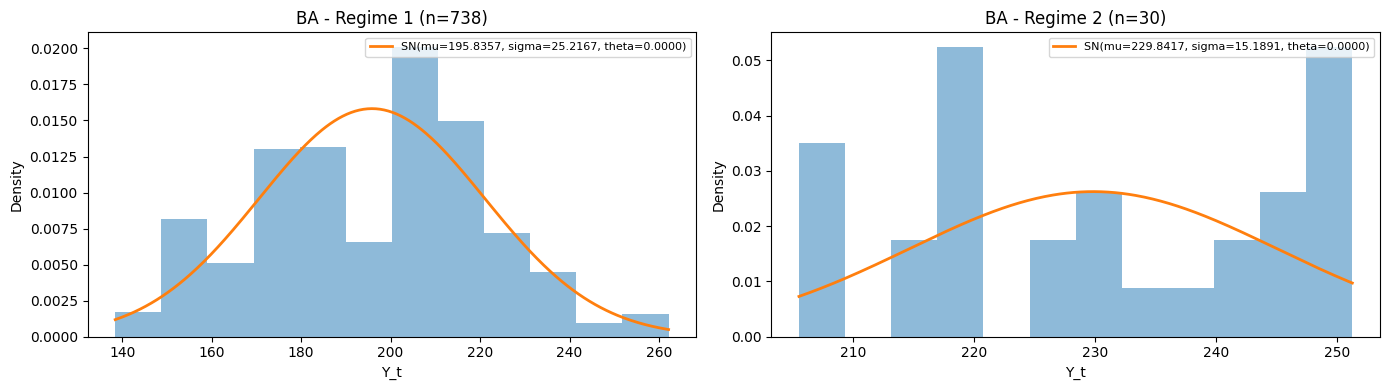

In [35]:
print(result_ba["interpretation"])
plot_ks_scan(result_ba)
plot_breakpoint(ba, result_ba)
plot_regime_histograms(ba, result_ba)

12. Show the results and figures for BAESY

For BAESY, the estimated rupture point is k_hat = 30 (2023-02-17). The KS statistic is 1.0000 and the p-value is 0.0000. Decision: Reject H0 at 0.05: evidence of a rupture. The skew-normal estimates are mu1 = 39.2649, sigma1 = 0.7634, mu2 = 69.2947, sigma2 = 20.2624, theta = 0.0000.


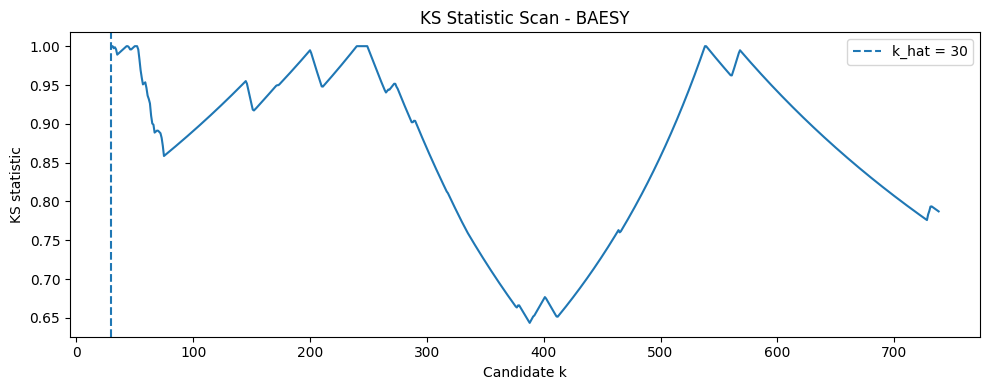

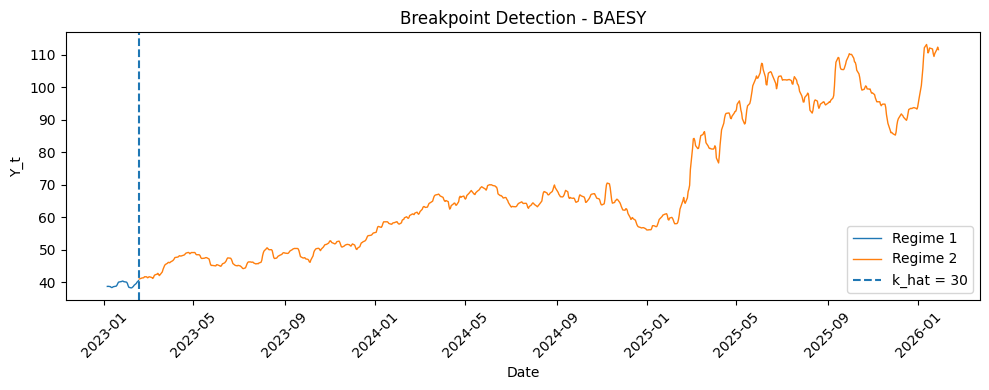

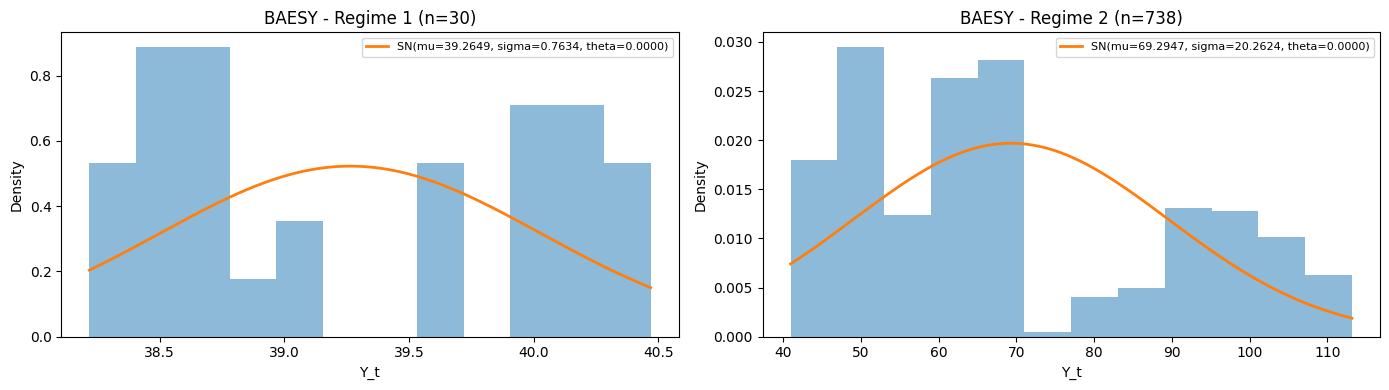

In [36]:
print(result_baesy["interpretation"])
plot_ks_scan(result_baesy)
plot_breakpoint(baesy, result_baesy)
plot_regime_histograms(baesy, result_baesy)

13. Show the results and figures for GD

For GD, the estimated rupture point is k_hat = 215 (2023-11-13). The KS statistic is 1.0000 and the p-value is 0.0000. Decision: Reject H0 at 0.05: evidence of a rupture. The skew-normal estimates are mu1 = 212.3395, sigma1 = 9.6885, mu2 = 285.5931, sigma2 = 31.8919, theta = 0.0000.


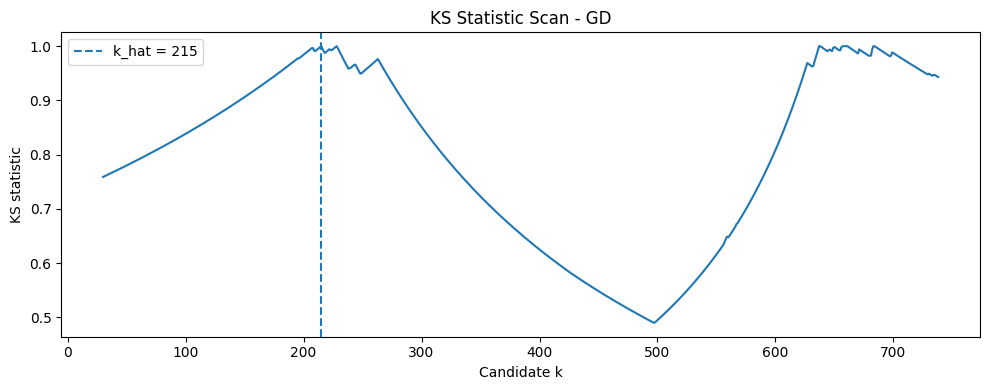

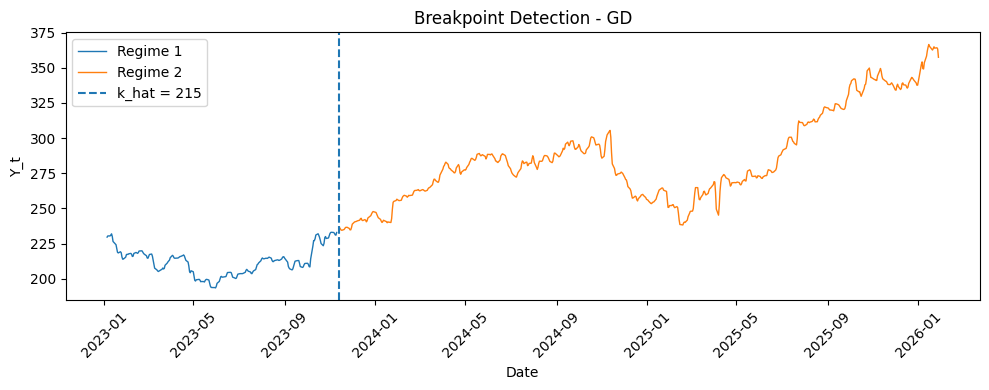

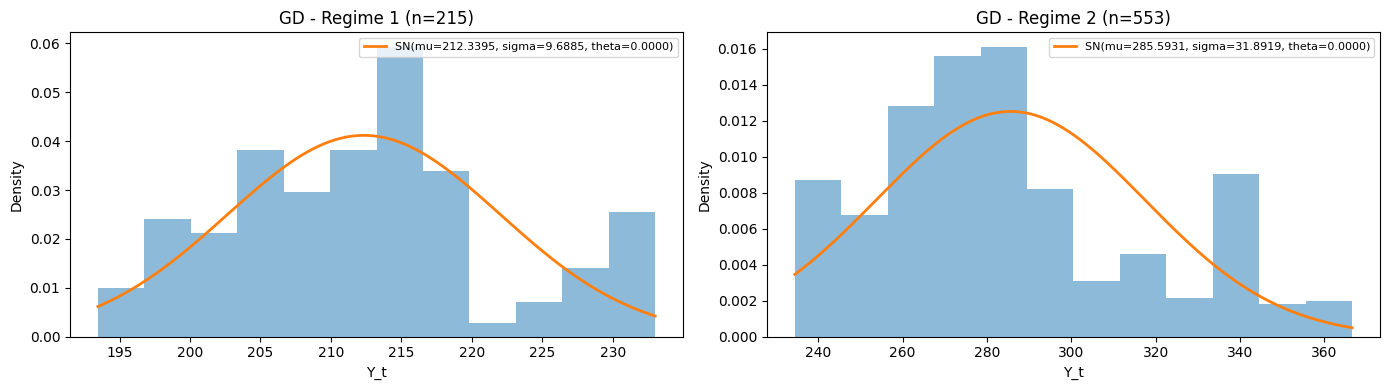

In [37]:
print(result_gd["interpretation"])
plot_ks_scan(result_gd)
plot_breakpoint(gd, result_gd)
plot_regime_histograms(gd, result_gd)

Export the results to JSON

In [38]:
import os
import json

os.makedirs(OUTPUT_DIR, exist_ok=True)

results = {
    "BA": result_ba,
    "BAESY": result_baesy,
    "GD": result_gd
}

for name, result in results.items():
    with open(f"{OUTPUT_DIR}/{name}.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=4, ensure_ascii=False)

print("Saved all JSON files.")

Saved all JSON files.
